In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
df = pd.read_csv("../dataset/original_dataset/ecommerce_orders_dataset.csv")

In [7]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [8]:
daily_revenue = (
    df.groupby("Order_Date")["Order_Amount"]
    .sum()
    .reset_index()
)

In [9]:
daily_revenue.head()

,Order_Date,Order_Amount
0,2023-01-01,10026.40
1,2023-01-02,8261.28
2,2023-01-03,8260.24
3,2023-01-04,8649.10
4,2023-01-05,7342.03


In [10]:
daily_revenue.info()

<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order_Date    1461 non-null   datetime64[us]
 1   Order_Amount  1461 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 23.0 KB


In [11]:
daily_revenue.describe()

,Order_Date,Order_Amount
count,1461,1461.000000
mean,2024-12-31 00:00:00,7782.370972
min,2023-01-01 00:00:00,1203.860000
25%,2024-01-01 00:00:00,5484.230000
50%,2024-12-31 00:00:00,7389.410000
75%,2025-12-31 00:00:00,9758.330000
max,2026-12-31 00:00:00,26576.790000
std,NaN,3239.887466


#### Daily Revenue

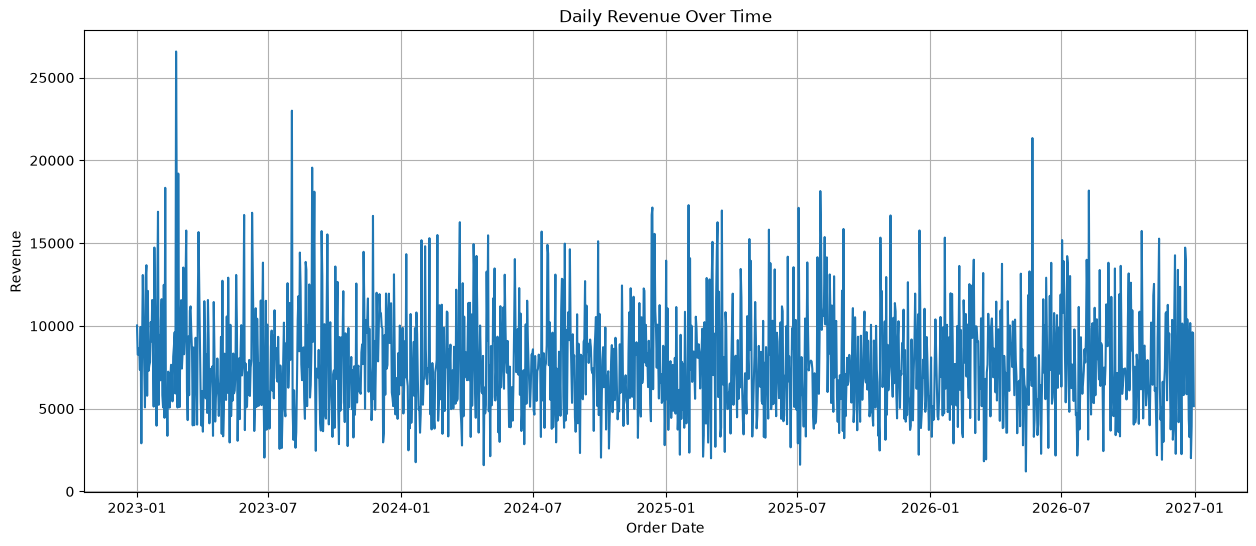

In [12]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_revenue["Order_Date"],
    daily_revenue["Order_Amount"]
)

plt.title("Daily Revenue Over Time")
plt.xlabel("Order Date")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

#### Monthly Revenue Trend

In [13]:
monthly_revenue = (
    daily_revenue
    .set_index("Order_Date")
    .resample("ME")["Order_Amount"]
    .sum()
    .reset_index()
)

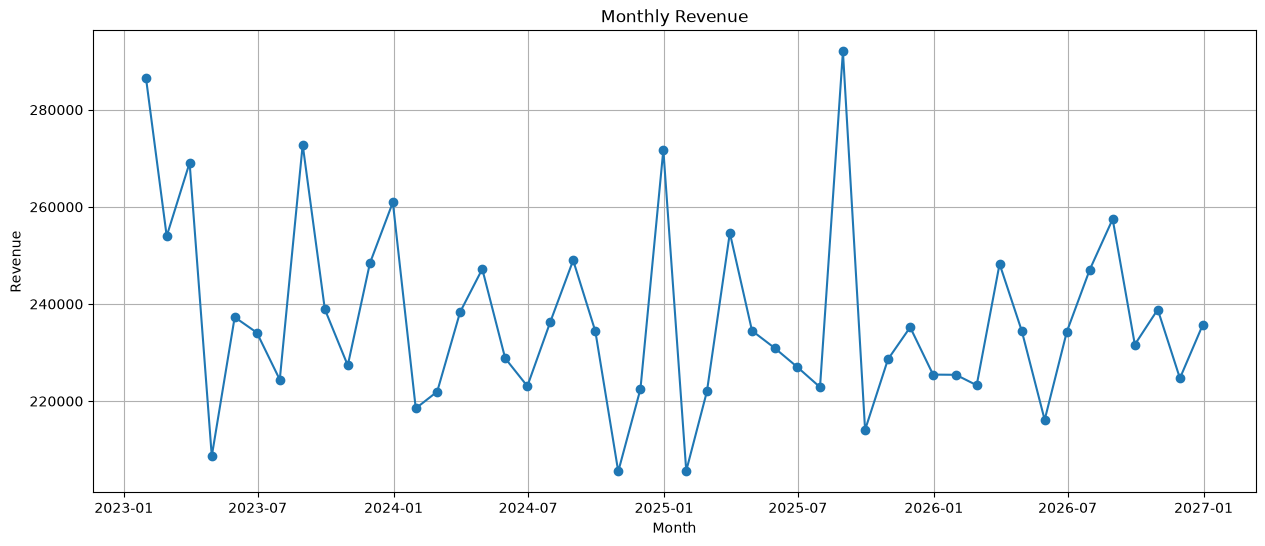

In [14]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_revenue["Order_Date"],
    monthly_revenue["Order_Amount"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

#### 30-Day Rolling Average Analysis

In [15]:
daily_revenue["Rolling_30_Days"] = (
    daily_revenue["Order_Amount"]
    .rolling(window=30)
    .mean()
)

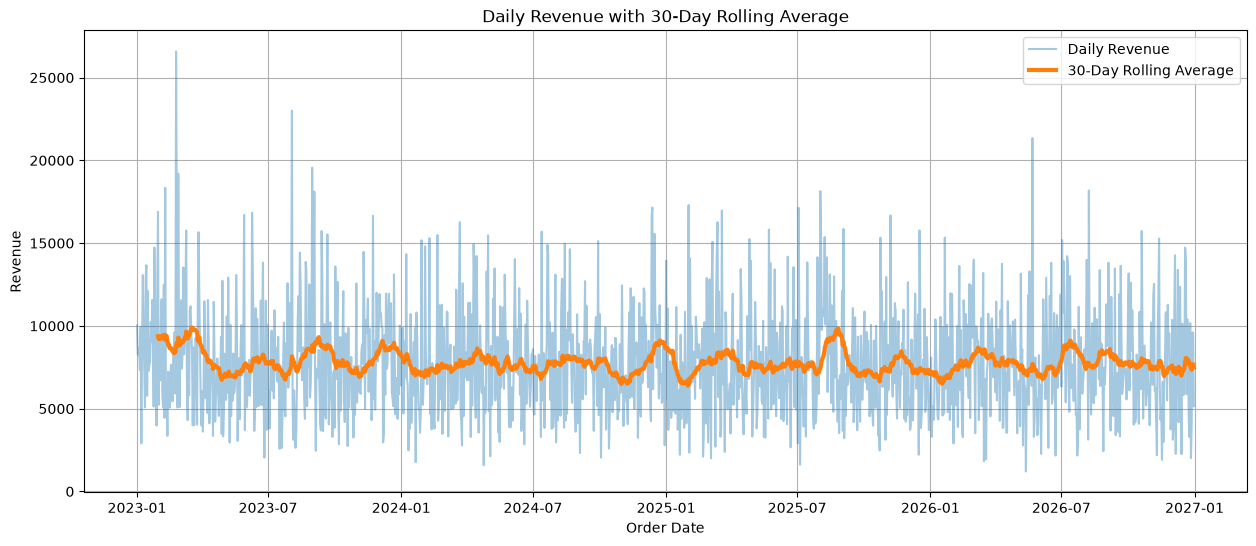

In [16]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_revenue["Order_Date"],
    daily_revenue["Order_Amount"],
    alpha=0.4,
    label="Daily Revenue"
)

plt.plot(
    daily_revenue["Order_Date"],
    daily_revenue["Rolling_30_Days"],
    linewidth=3,
    label="30-Day Rolling Average"
)

plt.title("Daily Revenue with 30-Day Rolling Average")
plt.xlabel("Order Date")
plt.ylabel("Revenue")

plt.legend()
plt.grid(True)

plt.show()

In [17]:
daily_revenue["Year"] = daily_revenue["Order_Date"].dt.year
daily_revenue["Month"] = daily_revenue["Order_Date"].dt.month
daily_revenue["Day"] = daily_revenue["Order_Date"].dt.day
daily_revenue["Day_of_Week"] = daily_revenue["Order_Date"].dt.dayofweek
daily_revenue["Quarter"] = daily_revenue["Order_Date"].dt.quarter

In [18]:
daily_revenue["Is_Weekend"] = (
    daily_revenue["Day_of_Week"] >= 5
).astype(int)

In [19]:
daily_revenue.head()

,Order_Date,Order_Amount,Rolling_30_Days,Year,Month,Day,Day_of_Week,Quarter,Is_Weekend
0,2023-01-01,10026.40,NaN,2023,1,1,6,1,1
1,2023-01-02,8261.28,NaN,2023,1,2,0,1,0
2,2023-01-03,8260.24,NaN,2023,1,3,1,1,0
3,2023-01-04,8649.10,NaN,2023,1,4,2,1,0
4,2023-01-05,7342.03,NaN,2023,1,5,3,1,0


#### Lag Features

In [20]:
daily_revenue["Lag_1"] = daily_revenue["Order_Amount"].shift(1)
daily_revenue["Lag_7"] = daily_revenue["Order_Amount"].shift(7)
daily_revenue["Lag_30"] = daily_revenue["Order_Amount"].shift(30)

In [21]:
daily_revenue.head(35)

,Order_Date,Order_Amount,Rolling_30_Days,Year,Month,Day,Day_of_Week,Quarter,Is_Weekend,Lag_1,Lag_7,Lag_30
0,2023-01-01,10026.40,NaN,2023,1,1,6,1,1,NaN,NaN,NaN
1,2023-01-02,8261.28,NaN,2023,1,2,0,1,0,10026.40,NaN,NaN
2,2023-01-03,8260.24,NaN,2023,1,3,1,1,0,8261.28,NaN,NaN
3,2023-01-04,8649.10,NaN,2023,1,4,2,1,0,8260.24,NaN,NaN
4,2023-01-05,7342.03,NaN,2023,1,5,3,1,0,8649.10,NaN,NaN
5,2023-01-06,9937.70,NaN,2023,1,6,4,1,0,7342.03,NaN,NaN
6,2023-01-07,2907.17,NaN,2023,1,7,5,1,1,9937.70,NaN,NaN
7,2023-01-08,8802.66,NaN,2023,1,8,6,1,1,2907.17,10026.40,NaN
8,2023-01-09,13074.65,NaN,2023,1,9,0,1,0,8802.66,8261.28,NaN
9,2023-01-10,9916.34,NaN,2023,1,10,1,1,0,13074.65,8260.24,NaN


#### Rolling Features

In [22]:
daily_revenue["Rolling_Mean_7"] = (
    daily_revenue["Order_Amount"]
    .rolling(window=7)
    .mean()
)
daily_revenue["Rolling_Mean_30"] = (
    daily_revenue["Order_Amount"]
    .rolling(window=30)
    .mean()
)
daily_revenue["Rolling_Std_7"] = (
    daily_revenue["Order_Amount"]
    .rolling(window=7)
    .std()
)

In [23]:
daily_revenue.head(40)

,Order_Date,Order_Amount,Rolling_30_Days,Year,Month,Day,Day_of_Week,Quarter,Is_Weekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30,Rolling_Std_7
0,2023-01-01,10026.40,NaN,2023,1,1,6,1,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-02,8261.28,NaN,2023,1,2,0,1,0,10026.40,NaN,NaN,NaN,NaN,NaN
2,2023-01-03,8260.24,NaN,2023,1,3,1,1,0,8261.28,NaN,NaN,NaN,NaN,NaN
3,2023-01-04,8649.10,NaN,2023,1,4,2,1,0,8260.24,NaN,NaN,NaN,NaN,NaN
4,2023-01-05,7342.03,NaN,2023,1,5,3,1,0,8649.10,NaN,NaN,NaN,NaN,NaN
5,2023-01-06,9937.70,NaN,2023,1,6,4,1,0,7342.03,NaN,NaN,NaN,NaN,NaN
6,2023-01-07,2907.17,NaN,2023,1,7,5,1,1,9937.70,NaN,NaN,7911.988571,NaN,2406.031345
7,2023-01-08,8802.66,NaN,2023,1,8,6,1,1,2907.17,10026.40,NaN,7737.168571,NaN,2267.250416
8,2023-01-09,13074.65,NaN,2023,1,9,0,1,0,8802.66,8261.28,NaN,8424.792857,NaN,3048.135271
9,2023-01-10,9916.34,NaN,2023,1,10,1,1,0,13074.65,8260.24,NaN,8661.378571,NaN,3097.111488


In [24]:
daily_revenue.isnull().sum()

Order_Date          0
Order_Amount        0
Rolling_30_Days    29
Year                0
Month               0
Day                 0
Day_of_Week         0
Quarter             0
Is_Weekend          0
Lag_1               1
Lag_7               7
Lag_30             30
Rolling_Mean_7      6
Rolling_Mean_30    29
Rolling_Std_7       6
dtype: int64

In [25]:
forecast_df = daily_revenue.dropna().reset_index(drop=True)

In [26]:
features = [
    "Year",
    "Month",
    "Day",
    "Day_of_Week",
    "Quarter",
    "Is_Weekend",
    "Lag_1",
    "Lag_7",
    "Lag_30",
    "Rolling_Mean_7",
    "Rolling_Mean_30",
    "Rolling_Std_7",
]

In [27]:
X = forecast_df[features]

y = forecast_df["Order_Amount"]

In [28]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (1431, 12)
Target Shape: (1431,)


### Time-Based Train-Test Split

In [29]:
split_index = int(len(forecast_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [30]:
print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))

Training samples : 1144
Testing samples  : 287


#### Train the Linear Regression Model

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 8.31,-80.76, -5.42,..., 1.21, -0.1 , -0.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['Year','Month','Day',...,'Rolling_Mean_7','Rolling_Mean_30', 'Rolling_Std_7']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.701e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


In [33]:
y_pred_lr = lr_model.predict(X_test)

In [34]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import numpy as np

In [35]:
mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2 = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 2367.80
RMSE : 2990.65
R²   : 0.1245


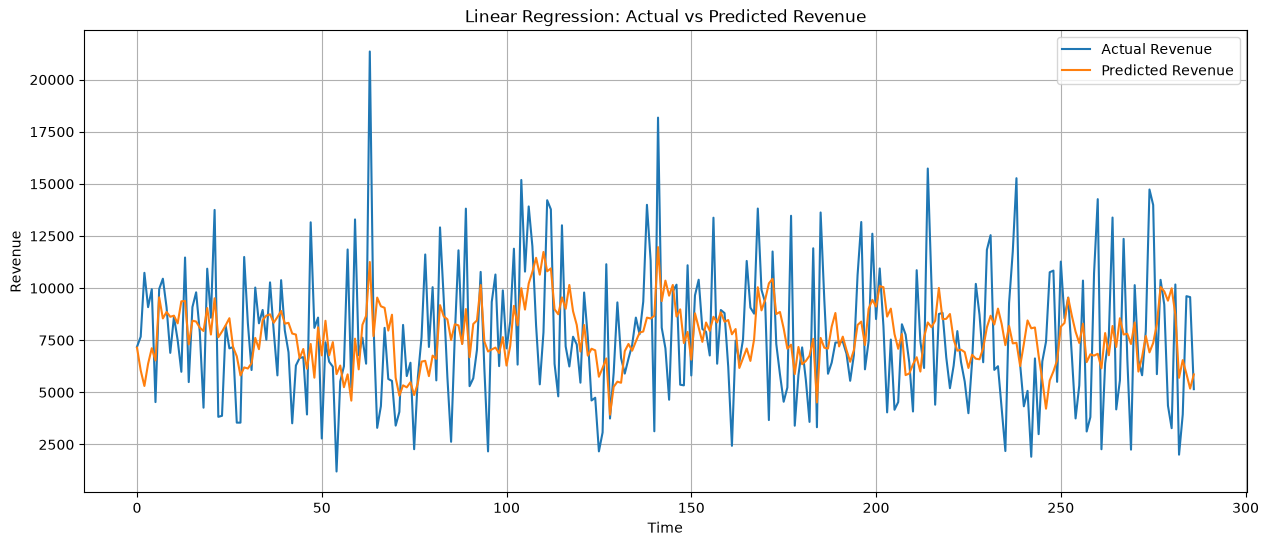

In [36]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.values,
    label="Actual Revenue"
)

plt.plot(
    y_pred_lr,
    label="Predicted Revenue"
)

plt.title("Linear Regression: Actual vs Predicted Revenue")
plt.xlabel("Time")
plt.ylabel("Revenue")

plt.legend()
plt.grid(True)

plt.show()

#### Random Forest Regressor

In [37]:
from sklearn.ensemble import RandomForestRegressor

In [38]:
"""
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
"""

'\nrf_model = RandomForestRegressor(\n    n_estimators=100,\n    random_state=42,\n    n_jobs=-1\n)\n'

In [39]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [40]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [41]:
y_pred_rf = rf_model.predict(X_test)

In [42]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

rf_r2 = r2_score(y_test, y_pred_rf)

print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

MAE  : 2370.08
RMSE : 2965.90
R²   : 0.1390


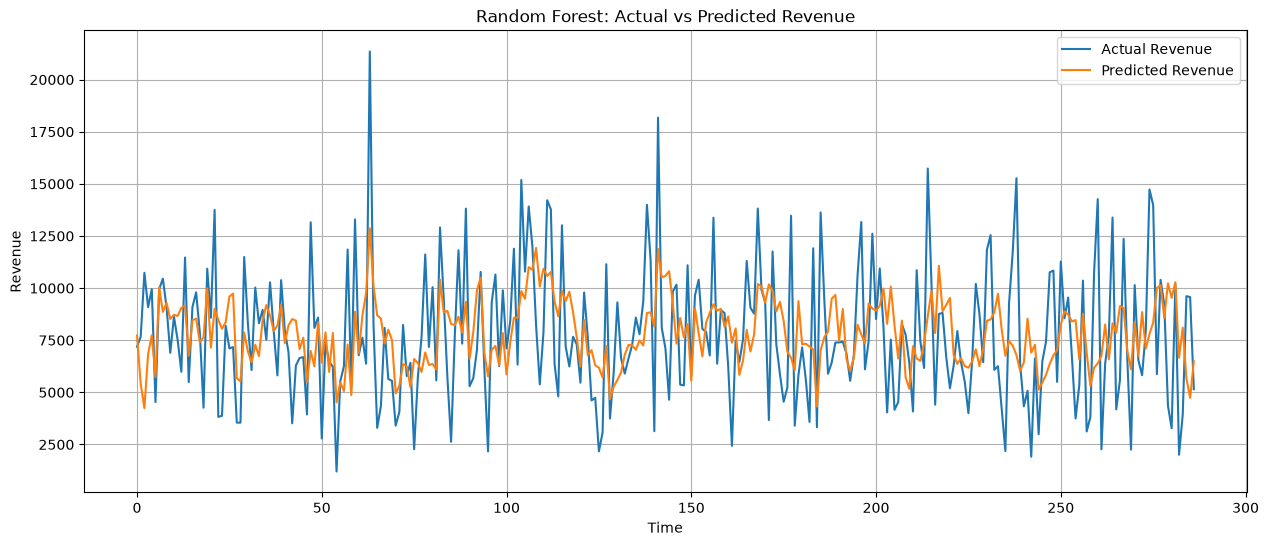

In [43]:
plt.figure(figsize=(15, 6))
plt.plot(y_test.values, label="Actual Revenue")
plt.plot(y_pred_rf, label="Predicted Revenue")
plt.title("Random Forest: Actual vs Predicted Revenue")
plt.xlabel("Time")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.show()

#### Feature Importance

In [44]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
9,Rolling_Mean_7,0.270715
11,Rolling_Std_7,0.162106
6,Lag_1,0.124766
8,Lag_30,0.104909
7,Lag_7,0.089597
10,Rolling_Mean_30,0.084495
2,Day,0.071470
3,Day_of_Week,0.032485
1,Month,0.028469
0,Year,0.019069


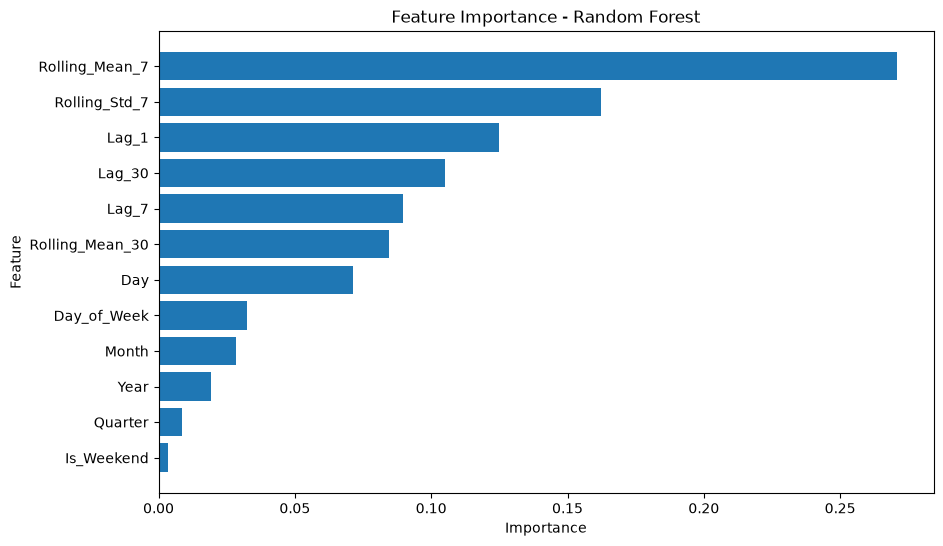

In [45]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

## XGBoost Regressor

In [46]:
from xgboost import XGBRegressor

In [47]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [48]:
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [49]:
y_pred_xgb = xgb_model.predict(X_test)

In [50]:
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

xgb_r2 = r2_score(y_test, y_pred_xgb)

print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

MAE  : 2492.86
RMSE : 3119.74
R²   : 0.0473


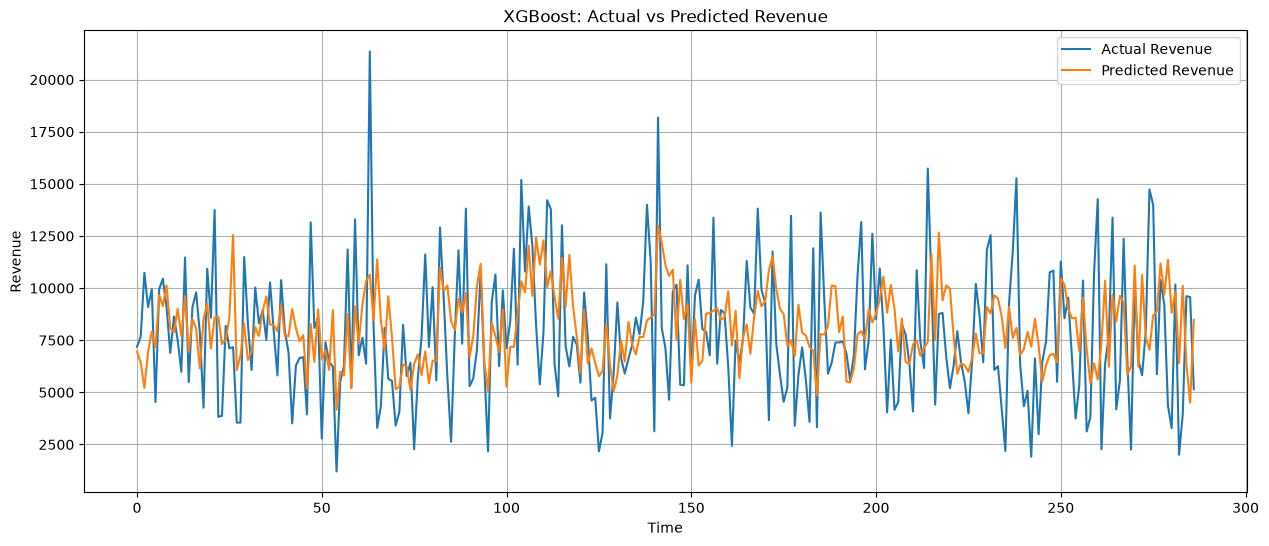

In [51]:
plt.figure(figsize=(15,6))
plt.plot(y_test.values, label="Actual Revenue")
plt.plot(y_pred_xgb, label="Predicted Revenue")
plt.title("XGBoost: Actual vs Predicted Revenue")
plt.xlabel("Time")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        r2,
        rf_r2,
        xgb_r2
    ]
})

comparison.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
1,Random Forest,2370.079206,2965.896614,0.138960
0,Linear Regression,2367.804993,2990.645514,0.124530
2,XGBoost,2492.858847,3119.740232,0.047317


In [53]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
9,Rolling_Mean_7,0.187210
11,Rolling_Std_7,0.117222
7,Lag_7,0.093293
8,Lag_30,0.089350
6,Lag_1,0.089267
10,Rolling_Mean_30,0.088141
2,Day,0.072465
3,Day_of_Week,0.062436
5,Is_Weekend,0.060189
1,Month,0.050904


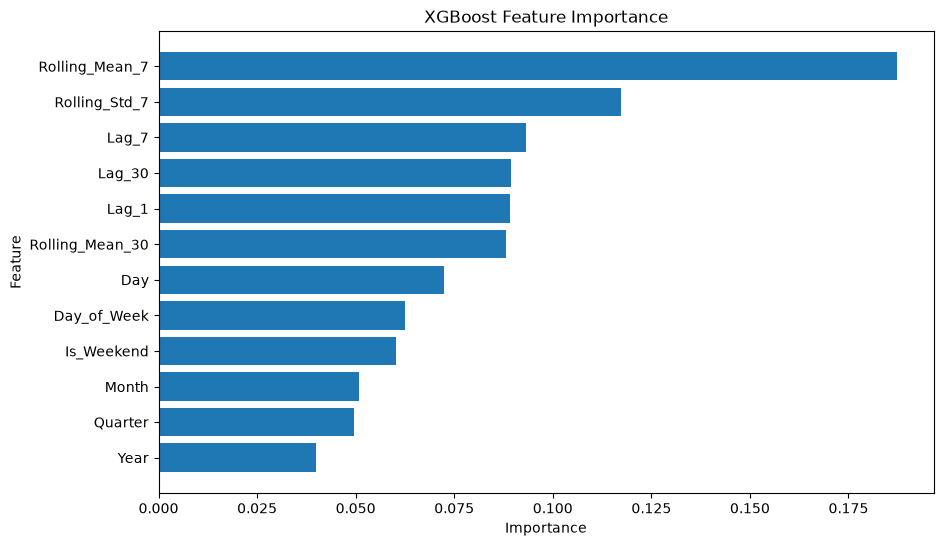

In [54]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

Random Forest achieved the highest R² score and the lowest RMSE, indicating the best overall predictive performance among the evaluated models. Therefore, it was selected as the final forecasting model.

In [55]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

In [56]:
tscv = TimeSeriesSplit(n_splits=5)

In [57]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)

In [58]:
cv_rmse = -cv_scores

In [59]:
print("RMSE for each fold")

for i, score in enumerate(cv_rmse, start=1):
    print(f"Fold {i}: {score:.2f}")

print(f"\nAverage RMSE: {cv_rmse.mean():.2f}")
print(f"Standard Deviation: {cv_rmse.std():.2f}")

RMSE for each fold
Fold 1: 3101.39
Fold 2: 2712.32
Fold 3: 3147.85
Fold 4: 2674.78
Fold 5: 3050.32

Average RMSE: 2937.33
Standard Deviation: 201.77


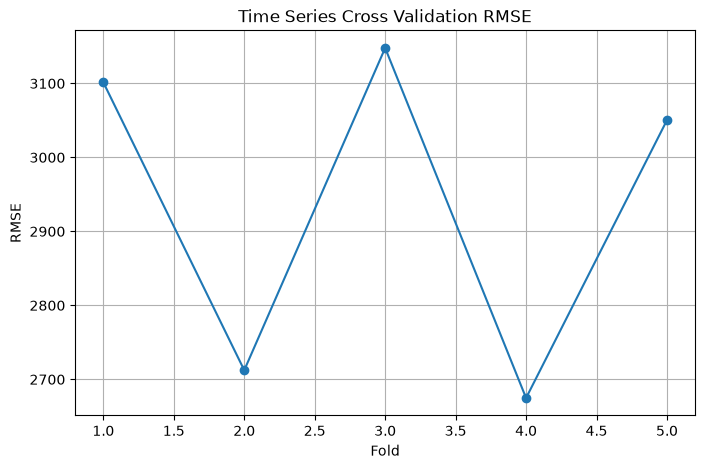

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cv_rmse) + 1),
    cv_rmse,
    marker="o"
)

plt.title("Time Series Cross Validation RMSE")
plt.xlabel("Fold")
plt.ylabel("RMSE")

plt.grid(True)

plt.show()

In [62]:
import joblib
joblib.dump(rf_model, "../models/revenue_forecast_rf.pkl")

['../models/revenue_forecast_rf.pkl']